In [1]:
import torch
import numpy as np
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
model = torch.hub.load('pytorch/vision:v0.14.0', 
                       'deeplabv3_resnet101', 
                       pretrained=True)
model.eval()

Using cache found in /Users/amolsatpute/.cache/torch/hub/pytorch_vision_v0.14.0
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [11]:
preprocess = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
                    ])

# Mean: [0.485, 0.456, 0.406] (for Red, Green, Blue channels respectively)
# Standard Deviation: [0.229, 0.224, 0.225] (for Red, Green, Blue channels respectively)

In [9]:
filepath = "./object_detection/image_for_object_detection.jpeg"

In [15]:
img = Image.open(filepath)

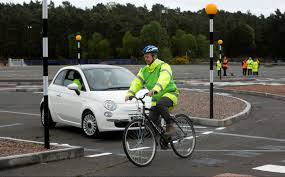

In [17]:
img

In [19]:
img1 = img.convert("RGB")

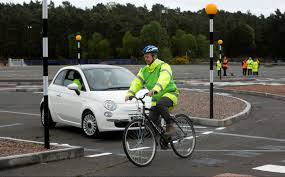

In [21]:
img1

In [25]:
preprocess(img1).shape

torch.Size([3, 177, 285])

In [29]:
input_tensor = preprocess(img1).unsqueeze(0)

In [31]:
input_tensor.shape

torch.Size([1, 3, 177, 285])

In [33]:
input_tensor

tensor([[[[ 1.7694,  2.0434,  1.9749,  ...,  1.8037,  1.8037,  1.8037],
          [ 2.0263,  1.7865,  2.0605,  ...,  1.8208,  1.8208,  1.8208],
          [ 1.2043,  1.6495,  0.6049,  ...,  1.8379,  1.8379,  1.8379],
          ...,
          [-0.9534, -0.9534, -0.9534,  ..., -0.5082, -0.5424, -0.6109],
          [-0.9705, -0.9534, -0.9363,  ..., -0.6623, -0.6281, -0.6281],
          [-1.0562, -1.0390, -0.9020,  ..., -0.7308, -0.7308, -0.7479]],

         [[ 2.0259,  2.3060,  2.2360,  ...,  2.0259,  2.0259,  2.0259],
          [ 2.2885,  2.0434,  2.3235,  ...,  2.0434,  2.0434,  2.0434],
          [ 1.4482,  1.9034,  0.8354,  ...,  2.0609,  2.0609,  2.0609],
          ...,
          [-0.8627, -0.8627, -0.8627,  ..., -0.4076, -0.4426, -0.5126],
          [-0.8803, -0.8627, -0.8452,  ..., -0.5651, -0.5301, -0.5301],
          [-1.0378, -1.0203, -0.8803,  ..., -0.7052, -0.7052, -0.7227]],

         [[ 2.3088,  2.5877,  2.5180,  ...,  2.3611,  2.3611,  2.3611],
          [ 2.5703,  2.3263,  

In [35]:
with torch.no_grad():
    output = model(input_tensor)

In [39]:
output.keys()

odict_keys(['out', 'aux'])

In [49]:
op = output["out"][0]

In [59]:
op.shape

torch.Size([21, 177, 285])

In [51]:
mask = op.argmax(0).cpu().numpy()

In [61]:
mask.shape

(177, 285)

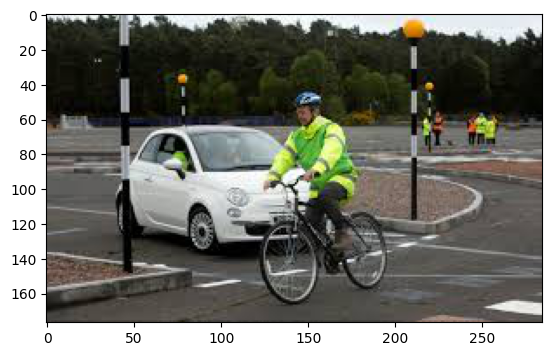

In [53]:
plt.imshow(img1)

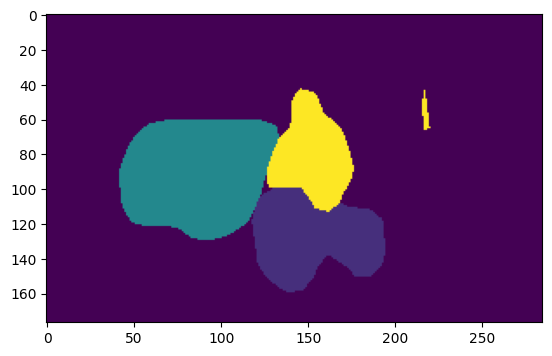

In [55]:
plt.imshow(mask)